# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [3]:
import os
import pandas as pd
import sys

# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults

gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/53/Resources"

In [50]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_NNwCCS3.gdx',
                        'MainResults_NNwCCS4.gdx',
                         'MainResults_NZwCCS.gdx'],
                    paths=['Balmorel/Project_NNwCCS/Model',
                            'Balmorel/Project_NNwCCS/Model',
                            'Balmorel/Project_NZwCCS/Model'],
                    scenario_names=['Net-Negative w CCS 3','Net-Negative w CCS 4','Net-zero w CCS'],
                    system_directory=gams_system_directory)


Loading Balmorel/Project_NNwCCS/Model/MainResults_NNwCCS3.gdx
Loading Balmorel/Project_NNwCCS/Model/MainResults_NNwCCS4.gdx
Loading Balmorel/Project_NZwCCS/Model/MainResults_NZwCCS.gdx


In [53]:
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))

In [34]:
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

In [54]:
PRO_YCRAF = pd.DataFrame(res.get_result('PRO_YCRAF'))

GamsException: Cannot find symbol PRO_YCRAF

In [37]:
print("EMI_YCRAG shape:", EMI_YCRAG.shape)
print("EMI_YCRAG index names:", EMI_YCRAG.index.names)
print("EMI_YCRAG columns:", EMI_YCRAG.columns.tolist())
print("\nUnique Years:", sorted(EMI_YCRAG['Y'].unique()))
print("Unique Scenarios:", sorted(EMI_YCRAG['Scenario'].unique()))
print("Unique Fuels (FFF):", sorted(EMI_YCRAG['FFF'].unique()))
print("\nFirst few rows:")
print(EMI_YCRAG.head(10))

EMI_YCRAG shape: (223, 10)
EMI_YCRAG index names: [None]
EMI_YCRAG columns: ['Scenario', 'Y', 'C', 'RRR', 'AAA', 'G', 'FFF', 'TECH_TYPE', 'UNITS', 'Value']

Unique Years: ['2030', '2050']
Unique Scenarios: ['Net-Negative w CCS 3', 'Net-Negative w CCS 4']
Unique Fuels (FFF): ['COAL', 'FUELOIL', 'LIGHTOIL', 'NATGAS', 'WOODCHIPS', 'WOODPELLETS', 'WOODWASTE']

First few rows:
               Scenario     Y       C  RRR     AAA  \
0  Net-Negative w CCS 3  2030  NORWAY  NO1  NO1_A2   
1  Net-Negative w CCS 3  2030  NORWAY  NO1  NO1_A3   
2  Net-Negative w CCS 3  2030  NORWAY  NO2  NO2_A2   
3  Net-Negative w CCS 3  2030  NORWAY  NO2  NO2_A2   
4  Net-Negative w CCS 3  2030  NORWAY  NO2  NO2_A2   
5  Net-Negative w CCS 3  2030  NORWAY  NO3  NO3_A2   
6  Net-Negative w CCS 3  2030  NORWAY  NO3  NO3_A3   
7  Net-Negative w CCS 3  2030  NORWAY  NO4  NO4_A2   
8  Net-Negative w CCS 3  2030  NORWAY  NO4  NO4_A2   
9  Net-Negative w CCS 3  2030  NORWAY  NO5  NO5_A2   

                              

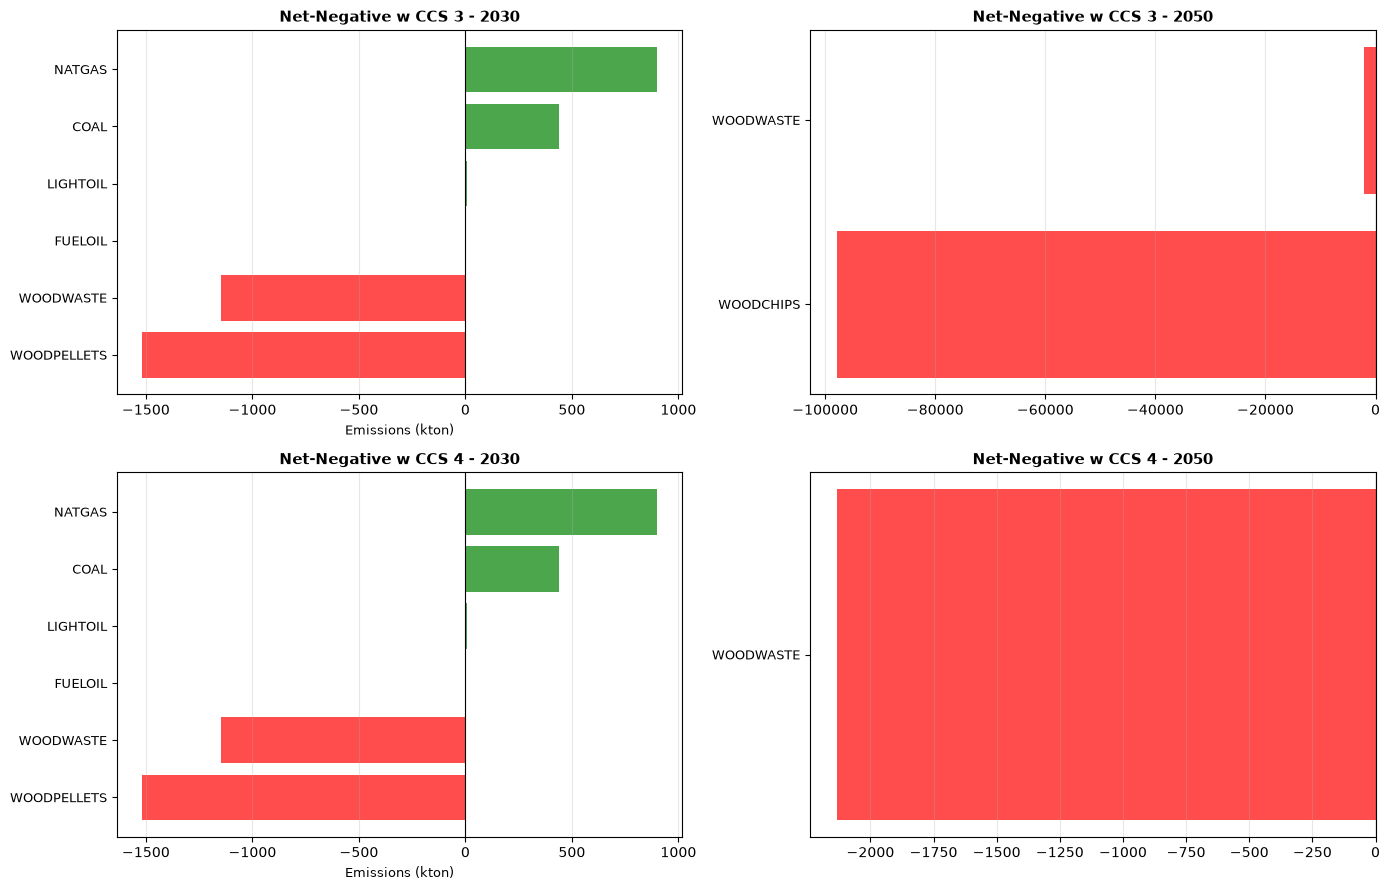

In [39]:
import matplotlib.pyplot as plt
import numpy as np


def plot_emissions_grid_by_year_and_scenario(emissions_df: pd.DataFrame, years: list = None, scenarios: list = None):
    """Plot emissions in a 2x2 grid (years as columns, scenarios as rows), grouped by fuel.

    Args:
        emissions_df (pd.DataFrame): Emissions results dataframe.
        years (list, optional): Years to plot. Defaults to all available.
        scenarios (list, optional): Scenarios to plot. Defaults to all available.

    Returns:
        tuple[plt.Figure, np.ndarray]: The figure and axes array.
    """
    # Get available years and scenarios
    if years is None:
        years = sorted(emissions_df['Y'].unique())
    else:
        years = [str(y) for y in years]  # Convert to strings to match data
    
    if scenarios is None:
        scenarios = sorted(emissions_df['Scenario'].unique())
    
    # Create 2x2 grid (rows=scenarios, columns=years)
    fig, axes = plt.subplots(len(scenarios), len(years), figsize=(14, 9))
    if len(scenarios) == 1 and len(years) == 1:
        axes = np.array([[axes]])
    elif len(scenarios) == 1:
        axes = axes.reshape(1, -1)
    elif len(years) == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each combination
    for i, scenario in enumerate(scenarios):
        for j, year in enumerate(years):
            ax = axes[i, j]
            
            # Filter data for this scenario and year
            filtered = emissions_df[(emissions_df['Scenario'] == scenario) & (emissions_df['Y'] == year)]
            
            if not filtered.empty:
                # Group by fuel type and sum emissions
                fuel_emissions = filtered.groupby('FFF')['Value'].sum().sort_values()
                
                # Plot as horizontal bar chart for better readability
                colors = ['red' if v < 0 else 'green' for v in fuel_emissions.values]
                ax.barh(range(len(fuel_emissions)), fuel_emissions.values, color=colors, alpha=0.7)
                ax.set_yticks(range(len(fuel_emissions)))
                ax.set_yticklabels(fuel_emissions.index, fontsize=9)
                ax.axvline(0, color='black', linewidth=0.8)
            
            ax.set_title(f"{scenario} - {year}", fontsize=11, fontweight='bold')
            ax.set_xlabel("Emissions (kton)" if j == 0 else "", fontsize=9)
            ax.grid(True, axis="x", alpha=0.3)
    
    plt.tight_layout()
    return fig, axes


# Plot 2x2 grid: rows=scenarios, columns=years
scenarios = ['Net-Negative w CCS 3', 'Net-Negative w CCS 4']
years = [2030, 2050]
fig, axes = plot_emissions_grid_by_year_and_scenario(EMI_YCRAG, years=years, scenarios=scenarios)

In [27]:
res.get_result

<bound method MainResults.get_result of <src.pybalmorel.classes.MainResults object at 0x133e186e0>>

In [ ]:
### 1.1.3 Plotting bar charts with an interactive gui
res.interactive_bar_chart()

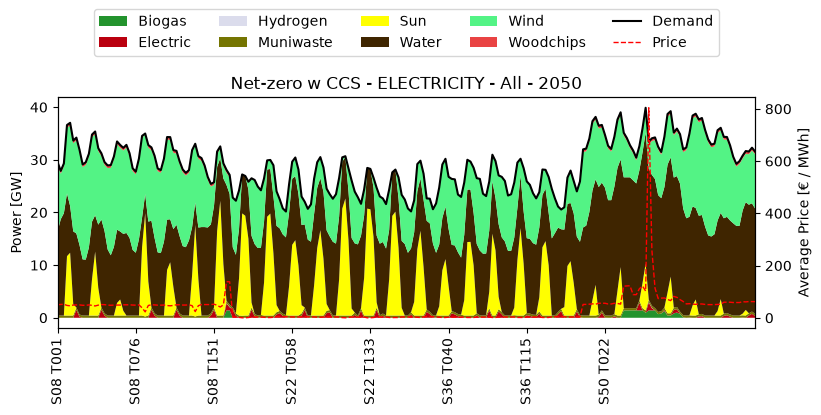

In [52]:
fig, ax = res.plot_profile(scenario='Net-zero w CCS', year=2050, commodity='Electricity', columns='Fuel')

No defined colour for WOODWASTE


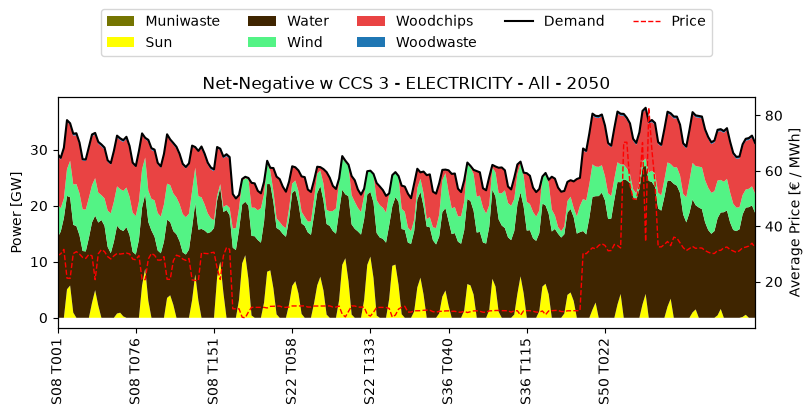

In [44]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS 3', year=2050, commodity='Electricity', columns='Fuel')

No defined colour for WOODWASTE


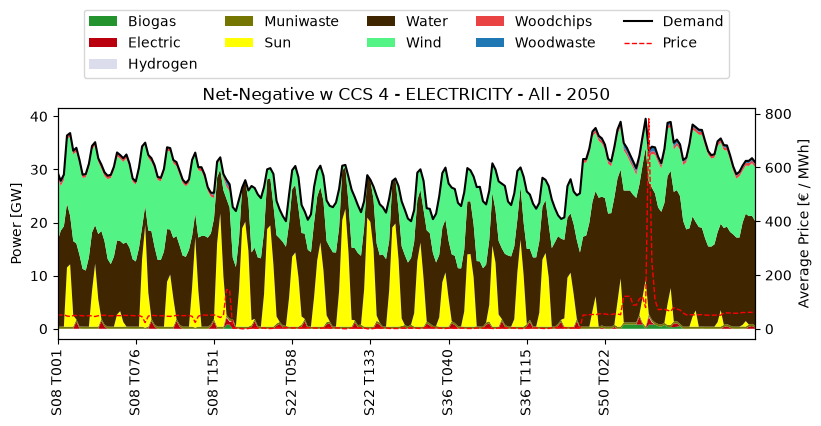

In [45]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS 4', year=2050, commodity='Electricity', columns='Fuel')

In [ ]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Fuel')

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Fuel')

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Technology')

In [ ]:
### 1.1.4 Plotting production profiles
fig, ax = res.plot_profile(scenario='Base Scenario', year=2050, commodity='Electricity', columns='Technology')


In [ ]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2030, commodity='Electricity', columns='Technology', region='DK2')

In [ ]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2050, commodity='Electricity', columns='Technology', region='DK1')

In [ ]:
fig, ax = res.plot_profile(scenario='Net-', year=2050, commodity='Electricity', columns='Technology')


In [ ]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2030, commodity='Electricity', columns='Technology', region='DK1')

In [ ]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2030, commodity='Electricity', columns='Technology', region='DK2')

In [ ]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2030, commodity='Electricity', columns='Technology', region='NO5')

In [ ]:
### 1.1.5 Plotting map of transmission capacity
fig, ax = res.plot_map(scenario='Base Scenario', year=2050, commodity='Electricity', lines='Capacity', generation='Capacity')